## Automatidata project

**Course 5 - Regression Analysis: Simplify complex data relationships**

The data consulting firm Automatidata has recently hired you as the newest member of their data analytics team. Their newest client, the NYC Taxi and Limousine Commission (New York City TLC), wants the Automatidata team to build a multiple linear regression model for ride durations based on a variety of variables. The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and A/B testing.

The Automatidata team has reviewed the results of the A/B testing. Now it’s time to work on predicting the taxi/ride share trip durations. You’ve impressed your Automatidata colleagues with your hard work and attention to detail. The data team believes that you are ready to build the regression model and update the client New York City TLC about your progress.

**Build a multiple linear regression model**
In this activity, will build a multiple linear regression model

**The purpose** of this project is to demostrate knowledge of EDA and a multiple linear regression model

**The goal** is to build a multiple linear regression model and evaluate the model
This activity has three parts:

**Part 1:** EDA & Checking Model Assumptions

**Part 2:** Model Building and evaluation

**Part 3:** Interpreting Model Results

**Build a multiple linear regression model**
Multiple linear regression helps to estimate the linear relationship between one continuous dependent variable and two or more independent variables. 

**PACE stages**
**PACE: Plan**

**Task 1. Imports and loading**

In [1]:
# Imports

# Packages for numerics + dataframes
import pandas as pd
import numpy as np

# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Packages for date conversions for calculating trip durations
from datetime import datetime
from datetime import date
from datetime import timedelta

# Packages for OLS, MLR, confusion matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error


In [2]:
#Import the data
taxi_data = pd.read_csv("2017_Yellow_Taxi_Trip_Data.csv",index_col = 0)
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


**PACE: Analyze**
- What are some purposes of EDA before constructing a multiple linear regression model?
1. EDA helps to understand the relationships between variables
2. Multiple regression is sensitive to predictors that are highly correlated with each other.Removing or combining correlated variables improves model stability and interpretability.
3. Regression is easily affected by poor data quality. EDA helps to identify outliers, misisng values, incorrect data types.
4. EDA helps to decide how to prepare the vatiables for modeling by performing transformations, binning or dummy encoding
5. EDA shows which variables have very large or very small ranges.
6. EDA can reveal clusters or groups that behave differently(eg, boxplot)

**Task 2a. Explore data with EDA**
Analyze and discover data, looking for correlations, missing data, outliers, and duplicates.

In [6]:
# Display the dataset's shape
print(taxi_data.shape)

# Display basic info about the dataset
taxi_data.info()

(22699, 17)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 22699 entries, 24870114 to 17208911
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               22699 non-null  int64  
 1   tpep_pickup_datetime   22699 non-null  object 
 2   tpep_dropoff_datetime  22699 non-null  object 
 3   passenger_count        22699 non-null  int64  
 4   trip_distance          22699 non-null  float64
 5   RatecodeID             22699 non-null  int64  
 6   store_and_fwd_flag     22699 non-null  object 
 7   PULocationID           22699 non-null  int64  
 8   DOLocationID           22699 non-null  int64  
 9   payment_type           22699 non-null  int64  
 10  fare_amount            22699 non-null  float64
 11  extra                  22699 non-null  float64
 12  mta_tax                22699 non-null  float64
 13  tip_amount             22699 non-null  float64
 14  tolls_amount           22699 non

**Task 2b. Create a new variable trip duration*

In [8]:
# convert  date columns to datetime in order to derive total trip duration.
taxi_data['tpep_pickup_datetime'] = pd.to_datetime(taxi_data['tpep_pickup_datetime'])
taxi_data['tpep_dropoff_datetime'] = pd.to_datetime(taxi_data['tpep_dropoff_datetime'])


In [10]:
#get the trip duraion in minutues
taxi_data['trip_duration_min'] = (taxi_data['tpep_dropoff_datetime']-taxi_data['tpep_pickup_datetime']).dt.total_seconds() / 60
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min
24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,14.066667
35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,26.500000
106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.200000
38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000
30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,16.716667


Check for missing data and duplicates using .isna() and .drop_duplicates().

In [11]:
taxi_data.isna().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
trip_duration_min        0
dtype: int64

In [12]:
# Display descriptive stats about the data
taxi_data.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min
count,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502,17.013777
std,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295,61.996482
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000,-16.983333
25%,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000,6.650000
50%,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000,11.183333
75%,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000,18.383333
max,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000,1439.550000


**Task 2c. Box plots to address any outliers**
Plot a box plot for each feature: trip_distance, fare_amount, duration.

<Axes: xlabel='trip_duration_min'>

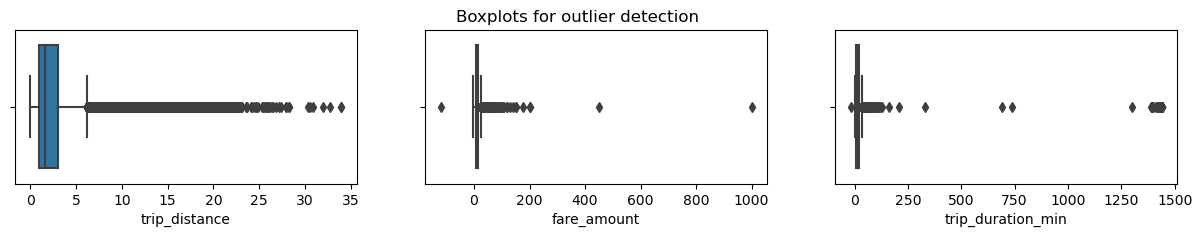

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for outlier detection')
sns.boxplot(ax=axes[0],x = taxi_data['trip_distance'] )
sns.boxplot(ax=axes[1],x = taxi_data['fare_amount'] )
sns.boxplot(ax=axes[2],x = taxi_data['trip_duration_min'] )

**Exemplar response:**
 1. All three variables show outliers—some are extreme, while others are relatively mild. 
 2. For trip_distance, the upper‑end values aren’t necessarily unreasonable. After all, the straight‑line distance from the southern tip of Staten Island to the northern end of Manhattan is roughly 30 miles, so long trips are possible. Given this context and the overall distribution, it’s reasonable to leave the trip_distance values as they are.

3. However, the fare_amount and duration variables have high‑end values that appear far less plausible. These outliers are likely problematic and may need to be investigated or handled before modeling.

**Task 2e. Imputations**
trip_distance **outliers**
We know from the summary statistics that there are trip distances of 0. Are these reflective of erroneous data, or are they very short trips that get rounded down?

To check, sort the column values, eliminate duplicates, and inspect the least 10 values. Are they rounded values or precise values?

In [35]:
list(taxi_data['trip_distance'].drop_duplicates().sort_values(ascending=True).head(10))

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

The distances are captured with a high degree of precision. However, it might be possible for trips to have distances of zero if a passenger summoned a taxi and then changed their mind. Besides, are there enough zero values in the data to pose a problem?

Calculate the count of rides where the trip_distance is zero.

In [36]:
(taxi_data['trip_distance'] == 0).sum()

148

**Exemplar note:** 148 out of ~23,000 rides is relatively insignificant.  impute it with a value of 0.01, but it's unlikely to have much of an effect on the model. Therefore, the trip_distance column will remain untouched with regard to outliers.

**fare_amount outliers**

In [38]:
taxi_data['fare_amount'].describe()

count    22699.000000
mean        13.026629
std         13.243791
min       -120.000000
25%          6.500000
50%          9.500000
75%         14.500000
max        999.990000
Name: fare_amount, dtype: float64

In [44]:
Q1 = taxi_data['fare_amount'].quantile(0.25)
Q3 = taxi_data['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
print(Q1,Q3,IQR)

6.5 14.5 8.0


**Exemplar response:**

The range of values in the fare_amount column is large and the extremes don't make much sense.

**Low values:** Negative values are problematic. Values of zero could be legitimate if the taxi logged a trip that was immediately canceled.

**High values:** The maximum fare amount in this dataset is nearly $1,000, which seems very unlikely. High values for this feature can be capped based on intuition and statistics. The interquartile range (IQR) is $8. The standard formula of Q3 + (1.5 * IQR) yields $26.50. That doesn't seem appropriate for the maximum fare cap. In this case, we'll use a factor of 6, which results in a cap of $62.50.

Impute values less than $0 with 0.

In [45]:
# Impute values less than $0 with 0
# Give the rows(fare amount less than 0) and columns(fare amount) as input for loc
taxi_data.loc[taxi_data['fare_amount'] < 0, 'fare_amount'] = 0
taxi_data['fare_amount'].min()

0.0

Now impute the maximum value as Q3 + (6 * IQR).

In [55]:
def outlier_imputer(column_list, iqr_factor):
    '''
    Impute upper-limit values in specified columns based on their interquartile range.

    Arguments:
        column_list: A list of columns to iterate over
        iqr_factor: A number representing x in the formula:
                    Q3 + (x * IQR). Used to determine maximum threshold,
                    beyond which a point is considered an outlier.

    The IQR is computed for each column in column_list and values exceeding
    the upper threshold for each column are imputed with the upper threshold value.
    '''
    for col in column_list:
        # Reassign minimum to zero
        taxi_data.loc[taxi_data['fare_amount'] < 0, 'fare_amount'] = 0
        
        # Calculate upper threshold
        q1 = taxi_data[col].quantile(0.25)
        q3 = taxi_data[col].quantile(0.75)
        iqr = q3 - q1
        upper_threshold = q3 + (iqr_factor * iqr)
        print('column name:',col)
        print('q3:', q3)
        print('upper_threshold:', upper_threshold)
        
        # Reassign values > threshold to threshold
        taxi_data.loc[taxi_data[col] > upper_threshold, col] = upper_threshold
        print(taxi_data[col].describe())


In [56]:
outlier_imputer(['fare_amount'],6)

column name: fare_amount
q3: 14.5
upper_threshold: 62.5
count    22699.000000
mean        12.897913
std         10.541137
min          0.000000
25%          6.500000
50%          9.500000
75%         14.500000
max         62.500000
Name: fare_amount, dtype: float64


**duration outliers**

In [57]:
taxi_data['trip_duration_min'].describe()

count    22699.000000
mean        17.013777
std         61.996482
min        -16.983333
25%          6.650000
50%         11.183333
75%         18.383333
max       1439.550000
Name: trip_duration_min, dtype: float64

The duration column has problematic values at both the lower and upper extremities.

**Low values:** There should be no values that represent negative time. Impute all negative durations with 0.

**High values:** Impute high values the same way we imputed the high-end outliers for fares: Q3 + (6 * IQR).

In [59]:
# Impute 0 for any negative values
taxi_data.loc[taxi_data['trip_duration_min'] < 0, 'trip_duration_min'] = 0
taxi_data['trip_duration_min'].min()

0.0

In [60]:
# Impute the high outliers
outlier_imputer(['trip_duration_min'],6)

column name: trip_duration_min
q3: 18.383333333333333
upper_threshold: 88.78333333333333
count    22699.000000
mean        14.460555
std         11.947043
min          0.000000
25%          6.650000
50%         11.183333
75%         18.383333
max         88.783333
Name: trip_duration_min, dtype: float64


**Task 3a. Feature engineering**
***Create mean_distance column***
When deployed, the model will not know the duration of a trip until after the trip occurs, so we cannot train a model that uses this feature. However, can use the statistics of trips we do know to generalize about ones we do not know.

In this step, create a column called mean_distance that captures the mean distance for each group of trips that share pickup and dropoff points.

For example, if data were:

Trip	Start	End	 Distance
1	A	B	1
2	C	D	2
3	A	B	1.5
4	D	C	3

The results should be:

A -> B: 1.25 miles
C -> D: 2 miles
D -> C: 3 miles
Notice that C -> D is not the same as D -> C. All trips that share a unique pair of start and end points get grouped and averaged.

Then, a new column ***mean_distance*** will be added where the value at each row is the average for all trips with those pickup and dropoff locations:

Trip	Start	End	Distance	mean_distance
1	A	B	1	1.25
2	C	D	2	2
3	A	B	1.5	1.25
4	D	C	3	3

Begin by creating a helper column called **pickup_dropoff**, which contains the unique combination of pickup and dropoff location IDs for each row.

One way to do this is to convert the pickup and dropoff location IDs to strings and join them, separated by a space. The space is to ensure that, for example, a trip with pickup/dropoff points of 12 & 151 gets encoded differently than a trip with points 121 & 51.

So, the new column would look like this:

Trip	Start	End	pickup_dropoff
1	A	B	'A B'
2	C	D	'C D'
3	A	B	'A B'
4	D	C	'D C'

In [61]:
# Create `pickup_dropoff` column
taxi_data['pickup_dropoff'] = taxi_data['PULocationID'].astype(str) + ' ' + taxi_data['DOLocationID'].astype(str)
taxi_data['pickup_dropoff'].head()

24870114     100 231
35634249      186 43
106203690    262 236
38942136      188 97
30841670       4 112
Name: pickup_dropoff, dtype: object

Now, use a groupby() statement to group each row by the new pickup_dropoff column, compute the mean, and capture the values only in the trip_distance column. Assign the results to a variable named grouped.

In [65]:
grouped = taxi_data.groupby(['pickup_dropoff'])[['trip_distance']].mean()
grouped[:5]

,trip_distance
pickup_dropoff,
1 1,2.433333
10 148,15.700000
100 1,16.890000
100 100,0.253333
100 107,1.180000


**grouped** is an object of the DataFrame class.

Convert it to a dictionary using the to_dict() method. Assign the results to a variable called grouped_dict. This will result in a dictionary with a key of trip_distance whose values are another dictionary. The inner dictionary's keys are pickup/dropoff points and its values are mean distances. This is the information needed.
**Example:**
grouped_dict = {'trip_distance': {'A B': 1.25, 'C D': 2, 'D C': 3}
Reassign the grouped_dict dictionary so it contains only the inner dictionary. In other words, get rid of trip_distance as a key, so:

Example:
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}

In [67]:
# 1. Convert `grouped` to a dictionary
grouped_dict = grouped.to_dict()
grouped_dict
# 2. Reassign to only contain the inner dictionary
grouped_dict = grouped_dict['trip_distance']

1. Create a mean_distance column that is a copy of the pickup_dropoff helper column.

2. Use the map() method on the mean_distance series. Pass grouped_dict as its argument. Reassign the result back to the mean_distance series. When passing a dictionary to the Series.map() method, it will replace the data in the series where that data matches the dictionary's keys. The values that get imputed are the values of the dictionary.

Example:
df['mean_distance']
mean_distance
'A B'
'C D'
'A B'
'D C'
'E F'
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}
df['mean_distance'] = df['mean_distance'].map(grouped_dict)
df['mean_distance']
mean_distance
1.25
2
1.25
3
NaN
When used this way, the map() Series method is very similar to replace(), however, note that map() will impute NaN for any values in the series that do not have a corresponding key in the mapping dictionary

In [68]:
# 1. Create a mean_distance column that is a copy of the pickup_dropoff helper column
taxi_data['mean_distance'] = taxi_data['pickup_dropoff']

# 2. Map `grouped_dict` to the `mean_distance` column
taxi_data['mean_distance'] = taxi_data['mean_distance'].map(grouped_dict)

# Confirm that it worked
taxi_data[(taxi_data['PULocationID']==100) & (taxi_data['DOLocationID']==231)][['mean_distance']]

,mean_distance
24870114,3.521667
96629892,3.521667
48945131,3.521667
50574134,3.521667
7282051,3.521667
49385419,3.521667


Create mean_duration column
Repeat the process used to create the mean_distance column to create a mean_duration column.

In [70]:
grouped = taxi_data.groupby(['pickup_dropoff'])[['trip_duration_min']].mean()

# Create a dictionary where keys are unique pickup_dropoffs and values are
# mean trip duration for all trips with those pickup_dropoff combos
grouped_dict = grouped.to_dict()
grouped_dict = grouped_dict['trip_duration_min']

#Map `grouped_dict` to the `mean_duration` column
taxi_data['mean_duration'] = taxi_data['pickup_dropoff']
taxi_data['mean_duration'] = taxi_data['mean_duration'].map(grouped_dict)

# Confirm that it worked
taxi_data[(taxi_data['PULocationID']==100) & (taxi_data['DOLocationID']==231)][['mean_duration']]

,mean_duration
24870114,22.847222
96629892,22.847222
48945131,22.847222
50574134,22.847222
7282051,22.847222
49385419,22.847222


**Create day and month columns**
Create two new columns, day (name of day) and month (name of month) by extracting the relevant information from the tpep_pickup_datetime column.

In [74]:
taxi_data['day'] = taxi_data['tpep_pickup_datetime'].dt.day_name().str.lower()
taxi_data['month'] = taxi_data['tpep_pickup_datetime'].dt.month_name().str[:3].str.lower()
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min,pickup_dropoff,mean_distance,mean_duration,day,month
24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,...,2.76,0.0,0.3,16.56,14.066667,100 231,3.521667,22.847222,saturday,mar
35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,...,4.00,0.0,0.3,20.80,26.500000,186 43,3.108889,24.470370,tuesday,apr
106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,...,1.45,0.0,0.3,8.75,7.200000,262 236,0.881429,7.250000,friday,dec
38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,...,6.39,0.0,0.3,27.69,30.250000,188 97,3.700000,30.250000,sunday,may
30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,...,0.00,0.0,0.3,17.80,16.716667,4 112,4.435000,14.616667,saturday,apr


**Create rush_hour column**
Define rush hour as:

Any weekday (not Saturday or Sunday) AND
Either from 06:00–10:00 or from 16:00–20:00
Create a binary rush_hour column that contains a 1 if the ride was during rush hour and a 0 if it was not.

In [78]:
# Create 'rush_hour' col
taxi_data['rush_hour'] = taxi_data['tpep_pickup_datetime'].dt.hour

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
taxi_data.loc[taxi_data['day'].isin(['saturday', 'sunday']),'rush_hour'] = 0

In [79]:
#define rush_hourizer function
#get the row of df to apply this function
def rush_hourizer(hourdf):
    if 6 <= hourdf['rush_hour'] < 10:
        val = 1
    elif 16 <= hourdf['rush_hour'] < 20:
        val = 1
    else:
        val = 0
    return val
    

In [81]:
# Apply the `rush_hourizer()` function to the new column
taxi_data.loc[(taxi_data['day'] != 'saturday') & (taxi_data['day'] != 'sunday'),'rush_hour'] = taxi_data.apply(rush_hourizer, axis=1)
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,trip_duration_min,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,...,0.0,0.3,16.56,14.066667,100 231,3.521667,22.847222,saturday,mar,0
35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,...,0.0,0.3,20.80,26.500000,186 43,3.108889,24.470370,tuesday,apr,0
106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,...,0.0,0.3,8.75,7.200000,262 236,0.881429,7.250000,friday,dec,1
38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,...,0.0,0.3,27.69,30.250000,188 97,3.700000,30.250000,sunday,may,0
30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,...,0.0,0.3,17.80,16.716667,4 112,4.435000,14.616667,saturday,apr,0


**Task 4. Scatter plot**
Create a scatterplot to visualize the relationship between mean_duration and fare_amount.

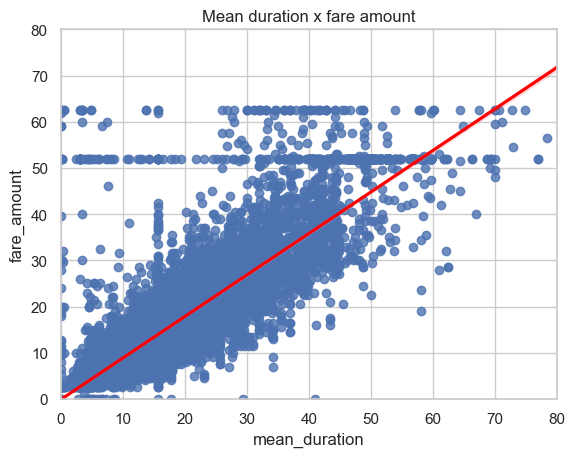

In [85]:
# Create a scatter plot of duration and trip_distance, with a line of best fit
sns.set(style='whitegrid')
sns.regplot(x=taxi_data['mean_duration'], y = taxi_data['fare_amount'],
           line_kws={'color':'red'})
plt.title('Mean duration x fare amount')
plt.ylim(0, 80)
plt.xlim(0, 80)
plt.show()

The mean_duration variable correlates with the target variable. But what are the horizontal lines around fare amounts of 52 dollars and 63 dollars? What are the values and how many are there?

You know what one of the lines represents. 62 dollars and 50 cents is the maximum that was imputed for outliers, so all former outliers will now have fare amounts of $62.50. What is the other line?

Check the value of the rides in the second horizontal line in the scatter plot.

In [86]:
taxi_data[taxi_data['fare_amount'] > 50]['fare_amount'].value_counts()

52.0    514
62.5     84
59.0      9
50.5      9
57.5      8
51.0      7
60.0      6
55.0      6
51.5      6
53.0      4
52.5      4
61.0      3
62.0      3
55.5      3
56.0      3
56.5      3
58.5      2
59.5      2
61.5      2
57.0      2
54.0      2
58.0      1
54.7      1
54.5      1
Name: fare_amount, dtype: int64

**Exemplar note:** There are 514 trips whose fares were $52.

Examine the first 30 of these trips.

In [90]:
pd.set_option('display.max_columns', None)
taxi_data[taxi_data['fare_amount'] == 52].head(30)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
18600059,2,2017-03-05 19:15:30,2017-03-05 19:52:18,2,18.90,2,N,236,132,1,52.0,0.0,0.5,14.58,5.54,0.3,72.92,36.800000,236 132,19.211667,40.500000,sunday,mar,0
47959795,1,2017-06-03 14:24:57,2017-06-03 15:31:48,1,18.00,2,N,132,163,1,52.0,0.0,0.5,0.00,0.00,0.3,52.80,66.850000,132 163,19.229000,52.941667,saturday,jun,0
95729204,2,2017-11-11 20:16:16,2017-11-11 20:17:14,1,0.23,2,N,132,132,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,0.966667,132 132,2.255862,3.021839,saturday,nov,0
103404868,2,2017-12-06 23:37:08,2017-12-07 00:06:19,1,18.93,2,N,132,79,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,29.183333,132 79,19.431667,47.275000,wednesday,dec,0
80479432,2,2017-09-24 23:45:45,2017-09-25 00:15:14,1,17.99,2,N,132,234,1,52.0,0.0,0.5,14.64,5.76,0.3,73.20,29.483333,132 234,17.654000,49.833333,sunday,sep,0
16226157,1,2017-02-28 18:30:05,2017-02-28 19:09:55,1,18.40,2,N,132,48,2,52.0,4.5,0.5,0.00,5.54,0.3,62.84,39.833333,132 48,18.761905,58.246032,tuesday,feb,1
55253442,2,2017-06-05 12:51:58,2017-06-05 13:07:35,1,4.73,2,N,228,88,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,15.616667,228 88,4.730000,15.616667,monday,jun,0
65900029,2,2017-08-03 22:47:14,2017-08-03 23:32:41,2,18.21,2,N,132,48,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,45.450000,132 48,18.761905,58.246032,thursday,aug,0
80904240,2,2017-09-26 13:48:26,2017-09-26 14:31:17,1,17.27,2,N,186,132,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,42.850000,186 132,17.096000,42.920000,tuesday,sep,0
33706214,2,2017-04-23 21:34:48,2017-04-23 22:46:23,6,18.34,2,N,132,148,1,52.0,0.0,0.5,5.00,0.00,0.3,57.80,71.583333,132 148,17.994286,46.340476,sunday,apr,0


**Exemplar response:**

It seems that almost all of the trips in the first 30 rows where the fare amount was $52 either begin or end at location 132, and all of them have a **RatecodeID** of 2.

There is no readily apparent reason why PULocation 132 should have so many fares of 52 dollars. They seem to occur on all different days, at different times, with both vendors, in all months. However, there are many toll amounts of $5.76 and $5.54. This would seem to indicate that location 132 is in an area that frequently requires tolls to get to and from. It's likely this is an airport.

The data dictionary says that RatecodeID of 2 indicates trips for JFK, which is John F. Kennedy International Airport. A quick Google search for "new york city taxi flat rate $52" indicates that in 2017 (the year that this data was collected) there was indeed a flat fare for taxi trips between JFK airport (in Queens) and Manhattan.

Because RatecodeID is known from the data dictionary, the values for this rate code can be imputed back into the data after the model makes its predictions. This way you know that those data points will always be correct.

**Task 5. Isolate modeling variables**
Drop features that are redundant, irrelevant, or that will not be available in a deployed environment.

In [93]:
df = taxi_data[['VendorID','passenger_count', 'fare_amount', 'mean_distance', 'mean_duration', 'rush_hour' ]].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22699 entries, 24870114 to 17208911
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.7 MB


**Task 6. Pair plot**
Create a pairplot to visualize pairwise relationships between fare_amount, mean_duration, and mean_distance.

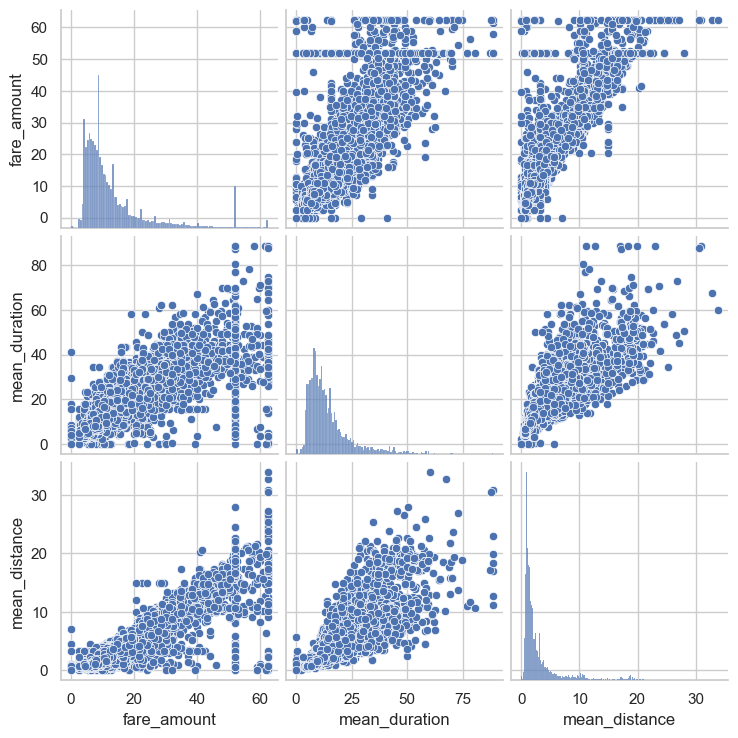

In [95]:
sns.pairplot(data = df[['fare_amount', 'mean_duration', 'mean_distance']])

These variables all show linear correlation with each other. Investigate this further.

**Task 7. Identify correlations**
Next, code a correlation matrix to help determine most correlated variables.

In [99]:
# Create correlation matrix containing pairwise correlation of columns, using pearson correlation coefficient
df.corr(method='pearson')

,VendorID,passenger_count,fare_amount,mean_distance,mean_duration,rush_hour
VendorID,1.000000,0.266463,0.001045,0.004741,0.001876,-0.002874
passenger_count,0.266463,1.000000,0.014942,0.013428,0.015852,-0.022035
fare_amount,0.001045,0.014942,1.000000,0.910185,0.859105,-0.020075
mean_distance,0.004741,0.013428,0.910185,1.000000,0.874864,-0.039725
mean_duration,0.001876,0.015852,0.859105,0.874864,1.000000,-0.021583
rush_hour,-0.002874,-0.022035,-0.020075,-0.039725,-0.021583,1.000000


Text(0.5, 1.0, 'Correlation heatmap')

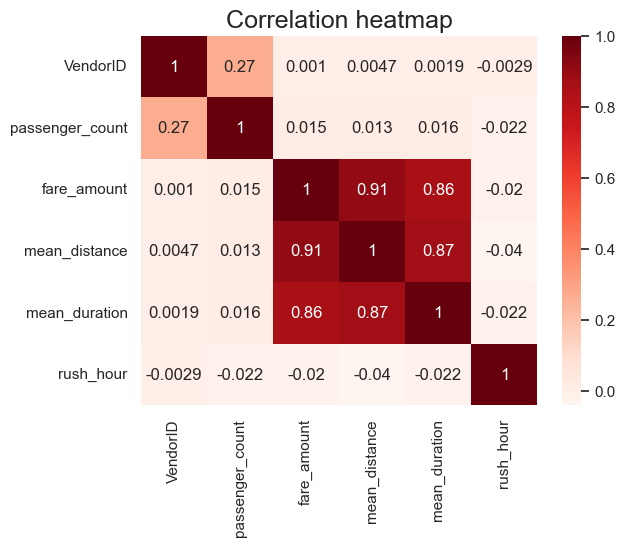

In [101]:
# Create correlation heatmap
sns.heatmap(df.corr(method='pearson'),annot=True,cmap='Reds' )
plt.title('Correlation heatmap',
          fontsize=18)

**Exemplar response:** 
Both **mean_duration and mean_distance** show strong correlations with the target variable **fare_amount.** They are also highly correlated with each other, with a Pearson correlation of 0.87.

Highly correlated predictors can be problematic in linear regression when the goal is to make statistical inferences, since multicollinearity makes it harder to interpret individual coefficients. However, if the primary objective is prediction, correlated predictors can still be useful and may even improve model performance.

In this case, the model’s purpose is to predict fare_amount, which will later serve as an input feature for machine learning models. Because prediction accuracy is the priority—not interpretability—it makes sense to include both variables in the model despite their correlation.

**PACE: Construct**
After analysis and deriving variables with close relationships, it is time to begin constructing the model. Consider the questions in PACE Strategy Document to reflect on the Construct stage.

**Task 8a. Split data into outcome variable and features**
Set X and y variables. X represents the features and y represents the outcome (target) variable.

In [96]:
# Remove the target column from the features
X = df.drop(columns = ['fare_amount'] )

# Set y variable
y = df[['fare_amount']]

# Display first few rows
X.head()

,VendorID,passenger_count,mean_distance,mean_duration,rush_hour
24870114,2,6,3.521667,22.847222,0
35634249,1,1,3.108889,24.470370,0
106203690,1,1,0.881429,7.250000,1
38942136,2,1,3.700000,30.250000,0
30841670,2,1,4.435000,14.616667,0


**Task 8b. Pre-process data**
Dummy encode categorical variables

In [97]:
# Convert VendorID to string
X['VendorID'] = X['VendorID'].astype(str)

# Get dummies
X = pd.get_dummies(X, drop_first = True)
X.head()

,passenger_count,mean_distance,mean_duration,rush_hour,VendorID_2
24870114,6,3.521667,22.847222,0,1
35634249,1,3.108889,24.470370,0,0
106203690,1,0.881429,7.250000,1,0
38942136,1,3.700000,30.250000,0,1
30841670,1,4.435000,14.616667,0,1


**Split data into training and test sets**
Create training and testing sets. The test set should contain 20% of the total samples. Set random_state=0.

In [102]:
# Create training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

If one feature has values in the thousands and another in decimals, the model can become biased toward the larger‑scale feature. StandardScaler fixes that.

**Standardize the data**
Use StandardScaler(), fit(), and transform() to standardize the X_train variables. Assign the results to a variable called X_train_scaled.

In [103]:
# Standardize the X variables
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
print('X_train scaled:', X_train_scaled)

X_train scaled: [[-0.50301524  0.8694684   0.17616665 -0.64893329  0.89286563]
 [-0.50301524 -0.60011281 -0.69829589  1.54099045  0.89286563]
 [ 0.27331093 -0.47829156 -0.57301906 -0.64893329 -1.11998936]
 ...
 [-0.50301524 -0.45121122 -0.6788917  -0.64893329 -1.11998936]
 [-0.50301524 -0.58944763 -0.85743597  1.54099045 -1.11998936]
 [ 1.82596329  0.83673851  1.13212101 -0.64893329  0.89286563]]


**Fit the model**
Instantiate your model and fit it to the training data.

In [104]:
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

**Task 8c. Evaluate model**
**Train data**
Evaluate your model performance by calculating the residual sum of squares and the explained variance score (R^2). Calculate the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error.

In [107]:
# Evaluate the model performance on the training data
r_sq = lr.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)

y_pred_train = lr.predict(X_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.8398434585044773
R^2: 0.8398434585044773
MAE: 2.186666416775413
MSE: 17.88973296349268
RMSE: 4.229625629236313


**Test data**
Calculate the same metrics on the test data. Remember to scale the X_test data using the scaler that was fit to the training data. Do not refit the scaler to the testing data, just transform it. Call the results X_test_scaled.

In [112]:
# Standardize the X variables
# Fitting the data with scaler only for train data and not for test data
X_test_scaled = scaler.transform(X_test)
print('X_test scaled:', X_test_scaled)

X_test scaled: [[-0.50301524 -0.01228033 -0.1109662  -0.64893329  0.89286563]
 [-0.50301524  0.1705781   0.83266676 -0.64893329  0.89286563]
 [ 0.27331093 -0.56800902 -0.71163492 -0.64893329  0.89286563]
 ...
 [-0.50301524 -0.5294519  -0.64990563 -0.64893329  0.89286563]
 [-0.50301524 -0.53660633 -0.83261981 -0.64893329 -1.11998936]
 [-0.50301524 -0.29519336 -0.17972406  1.54099045  0.89286563]]


In [113]:
# Evaluate the model performance on the test data

y_pred_test = lr.predict(X_test_scaled)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test, y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

R^2: 0.8682583641795454
MAE: 2.1336549840593855
MSE: 14.326454156998942
RMSE: 3.7850302716093225


**Exemplar note:** The model performs strongly on both the training and test sets, indicating low bias and suggesting that overfitting is not a concern. In fact, the test metrics are slightly better than the training metrics, which reinforces the model’s generalizability.

For the test data, an R² value of 0.868 means the model explains 86.8% of the variation in fare_amount, which reflects a high level of predictive power.

The MAE is particularly useful here because, for the purpose of model, an error of 2 dollars is not disproportionately worse than an error of 1 dollar. MAE captures this idea well by treating all errors linearly rather than penalizing larger errors more heavily.

**PACE: Execute**

**Task 9a. Results**
Get actual,predicted, and residual for the testing set, and store them as columns in a results dataframe.

In [121]:
#use ravel() to flatten an array into a 1‑dimensional array.
results = pd.DataFrame(data = {'actual' : y_test['fare_amount'],
                             'predicted' : y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
102188254,14.0,12.356503,1.643497
50574134,28.0,16.314595,11.685405
14767643,5.5,6.726789,-1.226789
16019414,15.5,16.227206,-0.727206
1352127,9.5,10.536408,-1.036408


**Task 9b. Visualize model results**
Create a scatterplot to visualize actual vs. predicted.

Text(0.5, 1.0, 'Actual vs Predicted Fare Amount')

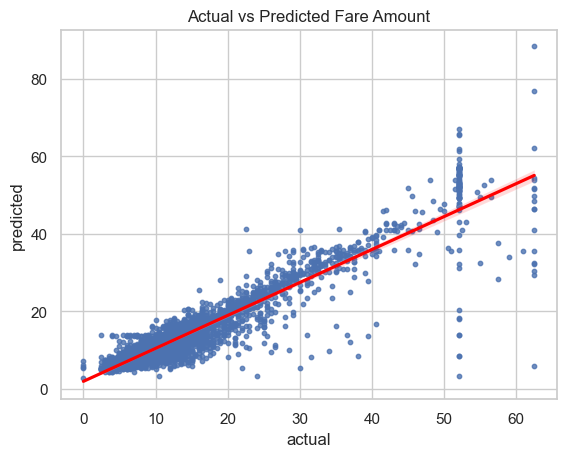

In [130]:
# Create a scatterplot to visualize `predicted` over `actual`
sns.regplot(x = results['actual'],
            y = results['predicted'],
            scatter_kws={'s': 10},   # marker size
            line_kws={'color': 'red'}
            )
#plt.axline((0,0), slope=1, color= 'red', linewidth = 2)
plt.title('Actual vs Predicted Fare Amount')

Visualize the distribution of the residuals using a histogram

Text(0, 0.5, 'count')

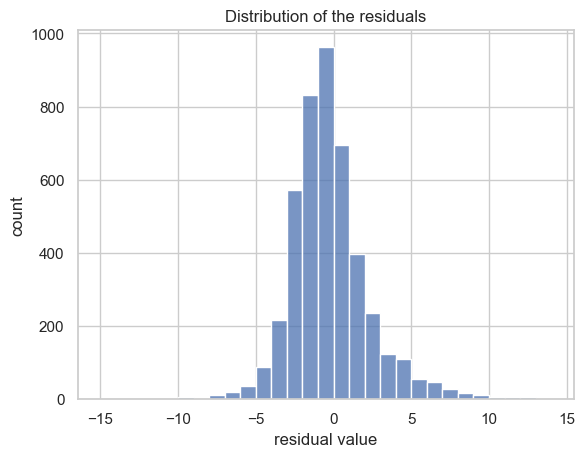

In [134]:
# Visualize the distribution of the `residuals`
sns.histplot(data = results['residual'], bins = np.arange(-15,15,1))
plt.title('Distribution of the residuals')
plt.xlabel('residual value')
plt.ylabel('count')

In [135]:
results['residual'].mean()

-0.015442621528680802

**Exemplar note:** The residuals appear to follow an approximately normal distribution and have a mean close to zero (−0.015). Residuals represent the portion of variation in the outcome variable that the model does not explain. A distribution centered around zero is a positive sign because it indicates that the model’s errors are balanced and do not show systematic bias.

Text(0.5, 1.0, 'Scatterplot of residuals over predicted values')

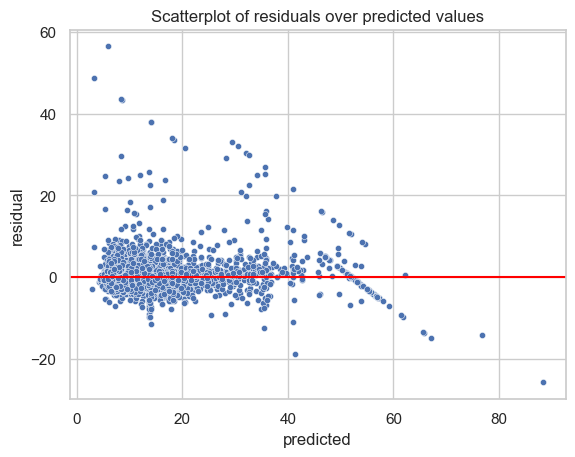

In [140]:
# Create a scatterplot of `residuals` over `predicted`
sns.scatterplot(x = results['predicted'],
            y = results['residual'],
            s = 20,   # marker size
            )
plt.axhline(c = 'red')
plt.title('Scatterplot of residuals over predicted values')

**Exemplar note:** The model's residuals are evenly distributed above and below zero, with the exception of the sloping lines from the upper-left corner to the lower-right corner, which you know are the imputed maximum of $62.50 and the flat rate of $52 for JFK airport trips.

In [141]:
lr.coef_

array([[ 0.03082453,  7.13386693,  2.81211486,  0.11023257, -0.05437345]])

In [142]:
# Get model coefficients
coefficients  = pd.DataFrame(lr.coef_, columns = X.columns)
coefficients 

,passenger_count,mean_distance,mean_duration,rush_hour,VendorID_2
0,0.030825,7.133867,2.812115,0.110233,-0.054373


The coefficients reveal that mean_distance was the feature with the greatest weight in the model's final prediction. A common misinterpretation is that for every mile traveled, the fare amount increases by a mean of $7.13. This is incorrect. The data used to train the model was standardized with StandardScaler(). As such, the units are no longer miles. In other words, we cannot say "for every mile traveled...", as stated above. The correct interpretation of this coefficient is: controlling for other variables, for every +1 change in standard deviation, the fare amount increases by a mean of $7.13

Also because some highly correlated features were not removed, the confidence interval of this assessment is wider.

So, translating this back to miles instead of standard deviation (i.e., unscale the data).

1. Calculate the standard deviation of mean_distance in the X_train data.

2. Divide the coefficient (7.133867) by the result to yield a more intuitive interpretation.

In [147]:
# 1. Calculate SD of `mean_distance` in X_train data
print(f"Std deviation of mean_distance: {X_train['mean_distance'].std()}")

# 2. Divide the model coefficient by the standard deviation
print(7.133867 / X_train['mean_distance'].std())

Std deviation of mean_distance: 3.574812975256415
1.9955916713344426


Now you can make a more intuitive interpretation: for every 3.57 miles traveled, the fare increased by a mean of $7.13. Or, reduced: for every 1 mile traveled, the fare increased by a mean of $2.00.

**Task 9d. Conclusion**
**Exemplar responses: What are the key takeaways from this notebook?**
1. Multiple linear regression is an effective method for predicting a continuous outcome using several independent variables. 
2. Exploratory data analysis plays an important role in identifying both numerical and categorical features that are suitable for inclusion in the model. 
3. Building a strong multiple regression model often involves some iteration, as testing different combinations of variables to achieve good predictive performance while still meeting the model’s underlying assumptions.

**What results can be presented from this notebook?**

Discuss meeting linear regression assumptions,and present the MAE and RMSE scores obtained from the model.

**BONUS CONTENT**
More work must be done to prepare the predictions to be used as inputs into the model for the upcoming course. This work will be broken into the following steps:

1. Get the model's predictions on the full dataset.

2. Impute the constant fare rate of 52 dollar for all trips with rate codes of 

3. Check the model's performance on the full dataset.

4. Save the final predictions and mean_duration and mean_distance columns for downstream use.

1. Get the model's predictions on the full dataset.

In [157]:
X_scaled = scaler.transform(X)
y_pred_full = lr.predict(X_scaled)

2. Impute ratecode 2 fare
The data dictionary says that the RatecodeID column captures the following information:

1 = standard rate
2 = JFK (airport)
3 = Newark (airport)
4 = Nassau or Westchester
5 = Negotiated fare
6 = Group ride

This means that some fares don't need to be predicted. They can simply be imputed based on their rate code. Specifically, all rate codes of 2 can be imputed with $52, as this is a flat rate for JFK airport.

The other rate codes have some variation. They are not a fixed rate, so these fares will remain untouched.

Impute 52 at all predictions where RatecodeID is 2.

In [169]:
# Create a new df containing just the RatecodeID col from the whole dataset
final_preds  = taxi_data[['RatecodeID']].copy()

# Add a column containing all the predictions
final_preds['y_pred_full'] = y_pred_full

# Impute a prediction of 52 at all rows where RatecodeID == 2
final_preds.loc[final_preds['RatecodeID'] == 2, 'y_pred_full'] = 52

# Check that it worked
final_preds[final_preds['RatecodeID'] == 2].head()

,RatecodeID,y_pred_full
18600059,2,52.0
47959795,2,52.0
95729204,2,52.0
103404868,2,52.0
80479432,2,52.0


Check performance on full dataset after updating the value of 52 for ratecode ID 2 

In [170]:
final_prediction = final_preds['y_pred_full']
print('R^2:', r2_score(y, final_prediction))
print('MAE:', mean_absolute_error(y, final_prediction))
print('MSE:', mean_squared_error(y, final_prediction))
print('RMSE:',np.sqrt(mean_squared_error(y, final_prediction)))

R^2: 0.8910853978683976
MAE: 1.9925062522699732
MSE: 12.10157550468993
RMSE: 3.4787318816905004


Save final predictions with mean_duration and mean_distance columns

In [173]:
# Combine means columns with predictions column
nyc_preds_means = taxi_data[['mean_duration', 'mean_distance']].copy()
nyc_preds_means['predicted_fare'] = final_prediction
nyc_preds_means.head()
nyc_preds_means.to_csv('nyc_preds_means.csv')

**NOTES**
This notebook was designed for as part of course. As such, there are some things to note that differ from best practice or from how tasks are typically performed.

1. When the mean_distance and mean_duration columns were computed, the means were calculated from the entire dataset. These same columns were then used to train a model that was used to predict on a test set. A test set is supposed to represent entirely new data that the model has not seen before, but in this case, some of its predictor variables were derived using data that was in the test set. This is known as data leakage. Data leakage is when information from your training data contaminates the test data. If your model has unexpectedly high scores, there is a good chance that there was some data leakage. To avoid data leakage in this modeling process, it would be best to compute the means using only the training set and then copy those into the test set, thus preventing values from the test set from being included in the computation of the means. This would have created some problems because it's very likely that some combinations of pickup-dropoff locations would only appear in the test data (not the train data). This means that there would be NaNs in the test data, and further steps would be required to address this. In this case, the data leakage improved the R2 score by ~0.03.
2. Imputing the fare amount for RatecodeID 2 after training the model and then calculating model performance metrics on the post-imputed data is not best practice. It would be better to separate the rides that did not have rate codes of 2, train the model on that data specifically, and then add the RatecodeID 2 data (and its imputed rates) after. This would prevent training the model on data that you don't need a model for, and would likely result in a better final model. However, the steps were combined for simplicity.
3. Models that predict values to be used in another downstream model are common in data science workflows. When models are deployed, the data cleaning, imputations, splits, predictions, etc. are done using modeling pipelines. Pandas was used here to granularize and explain the concepts of certain steps, but this process would be streamlined by machine learning engineers. The ideas are the same, but the implementation would differ. Once a modeling workflow has been validated, the entire process can be automated, often with no need for pandas and no need to examine outputs at each step. 